In [53]:
# importing necessary ML libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV





In [54]:
prices_data = pd.read_csv(r"D:\Ammar 2\CCAS.2.6 Summer\Final project\Regression_dataset\regression Egypt property prices.csv")


In [55]:
prices_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15311 entries, 0 to 15310
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Type            15311 non-null  object
 1   Price           15306 non-null  object
 2   Bedrooms        15310 non-null  object
 3   Bathrooms       15310 non-null  object
 4   Area            15300 non-null  object
 5   Furnished       15311 non-null  object
 6   Level           15311 non-null  object
 7   Compound        15311 non-null  object
 8   Payment_Option  15311 non-null  object
 9   Delivery_Date   15311 non-null  object
 10  Delivery_Term   15311 non-null  object
 11  City            12574 non-null  object
 12  Ad_Date         12583 non-null  object
 13  Scraping_Date   15311 non-null  object
dtypes: object(14)
memory usage: 1.6+ MB


In [56]:
#converting numerical columns no numerical values instead of string
#I used errors = 'coerce' to automatically turns any non-numeric values into NAN
prices_data['Price'] = pd.to_numeric(prices_data['Price'], errors='coerce')
prices_data['Bedrooms'] = pd.to_numeric(prices_data['Bedrooms'], errors='coerce')
prices_data['Bathrooms'] = pd.to_numeric(prices_data['Bathrooms'], errors='coerce')
prices_data['Area'] = pd.to_numeric(prices_data['Area'], errors='coerce')
prices_data['Level'] = pd.to_numeric(prices_data['Level'], errors='coerce')

prices_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15311 entries, 0 to 15310
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Type            15311 non-null  object 
 1   Price           12578 non-null  float64
 2   Bedrooms        12582 non-null  float64
 3   Bathrooms       12582 non-null  float64
 4   Area            12572 non-null  float64
 5   Furnished       15311 non-null  object 
 6   Level           9814 non-null   float64
 7   Compound        15311 non-null  object 
 8   Payment_Option  15311 non-null  object 
 9   Delivery_Date   15311 non-null  object 
 10  Delivery_Term   15311 non-null  object 
 11  City            12574 non-null  object 
 12  Ad_Date         12583 non-null  object 
 13  Scraping_Date   15311 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.6+ MB


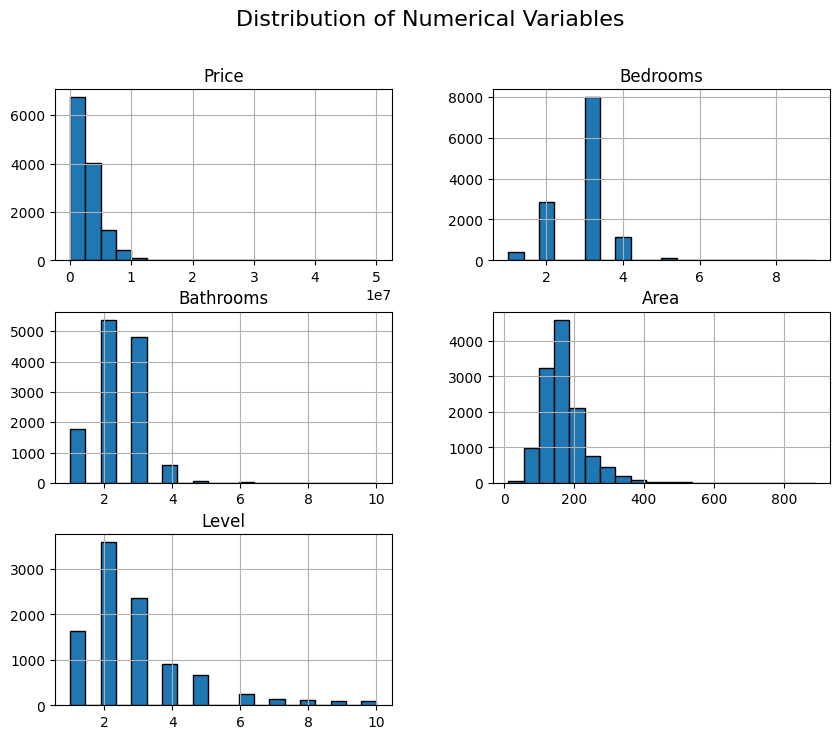

In [57]:
numerical_cols = ["Price", "Bedrooms", "Bathrooms", "Area", "Level"]

prices_data[numerical_cols].hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.show()

In [58]:
#chacking for missing values
prices_data.isnull().sum()


Type                 0
Price             2733
Bedrooms          2729
Bathrooms         2729
Area              2739
Furnished            0
Level             5497
Compound             0
Payment_Option       0
Delivery_Date        0
Delivery_Term        0
City              2737
Ad_Date           2728
Scraping_Date        0
dtype: int64

In [59]:
#Here I will fill missing values
#for numerical values I will fill with median not mean because meaan is more sensetive to outliers
# for categorical values I will fill with mode (most frequent value)
prices_data['Price'].fillna(prices_data['Price'].median(), inplace=True)
prices_data['Bedrooms'].fillna(prices_data['Bedrooms'].median(), inplace=True)
prices_data['Bathrooms'].fillna(prices_data['Bathrooms'].median(), inplace=True)
prices_data['Area'].fillna(prices_data['Area'].median(), inplace=True)
prices_data['City'].fillna(prices_data['City'].mode()[0], inplace=True)
prices_data['Ad_Date'].fillna(prices_data['Ad_Date'].mode()[0], inplace=True)

prices_data.isnull().sum()


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_13332\3691688320.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prices_data['Price'].fillna(prices_data['Price'].median(), inplace=True)
C:\Users\Ahmed\AppData\Local\Temp\ipykernel_13332\3691688320.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

Type                 0
Price                0
Bedrooms             0
Bathrooms            0
Area                 0
Furnished            0
Level             5497
Compound             0
Payment_Option       0
Delivery_Date        0
Delivery_Term        0
City                 0
Ad_Date              0
Scraping_Date        0
dtype: int64

In [60]:
prices_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15311 entries, 0 to 15310
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Type            15311 non-null  object 
 1   Price           15311 non-null  float64
 2   Bedrooms        15311 non-null  float64
 3   Bathrooms       15311 non-null  float64
 4   Area            15311 non-null  float64
 5   Furnished       15311 non-null  object 
 6   Level           9814 non-null   float64
 7   Compound        15311 non-null  object 
 8   Payment_Option  15311 non-null  object 
 9   Delivery_Date   15311 non-null  object 
 10  Delivery_Term   15311 non-null  object 
 11  City            15311 non-null  object 
 12  Ad_Date         15311 non-null  object 
 13  Scraping_Date   15311 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.6+ MB


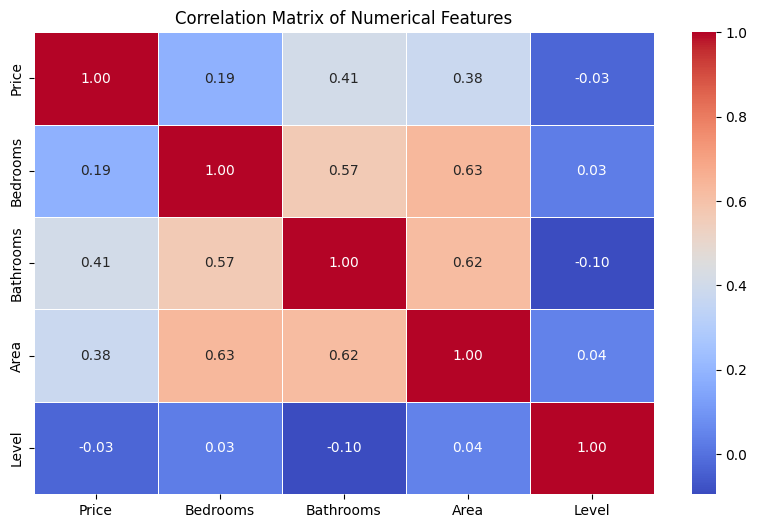

In [61]:
#plotting correlation matrix to show how feeatures are most related to each other and with price
num_columns = prices_data.select_dtypes(include=['float64', 'int64']).columns #selecting only numerical columns
correlation_matrix = prices_data[num_columns].corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

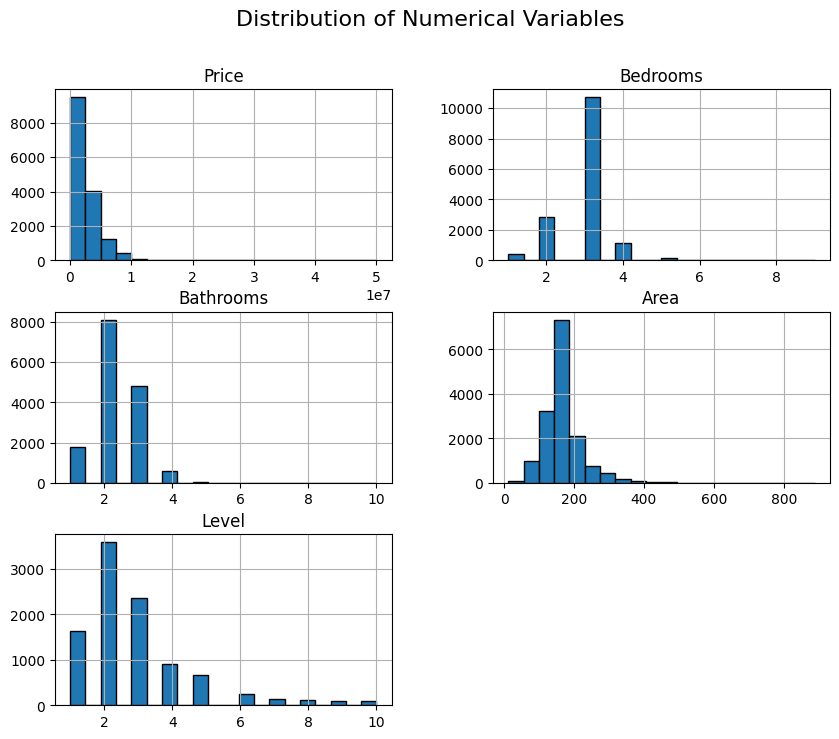

In [62]:
numerical_cols = ["Price", "Bedrooms", "Bathrooms", "Area", "Level"]

prices_data[numerical_cols].hist(figsize=(10, 8), bins=20, layout=(3, 2),   edgecolor='black')
plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.show()

In [63]:
#feature selection, 
#here i will drop level because of too many missing values 
# I will also remove data scraping date cause it add no predictive power to the model
#Since we are predicitng price,, I will also remove delivery and ad date cause they are weak predictors for price
prices_data.drop(columns=['Level', 'Scraping_Date','Delivery_Date','Ad_Date'], inplace=True)
#prices_data.info()

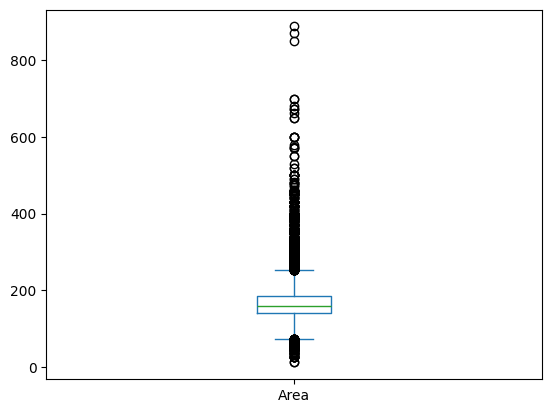

In [64]:
# Box plot to check for outliers in Area feature
prices_data['Area'].plot(kind='box')
plt.show()

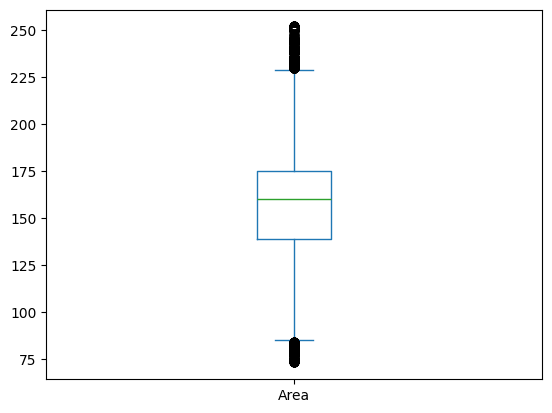

<class 'pandas.core.frame.DataFrame'>
Index: 13968 entries, 0 to 15310
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Type            13968 non-null  object 
 1   Price           13968 non-null  float64
 2   Bedrooms        13968 non-null  float64
 3   Bathrooms       13968 non-null  float64
 4   Area            13968 non-null  float64
 5   Furnished       13968 non-null  object 
 6   Compound        13968 non-null  object 
 7   Payment_Option  13968 non-null  object 
 8   Delivery_Term   13968 non-null  object 
 9   City            13968 non-null  object 
dtypes: float64(4), object(6)
memory usage: 1.2+ MB


In [65]:
#removing outliers in Area feature
#as we can see 1343 outliers were removed and the more we run the more they will be removed cause IQR is updated
Q1 = prices_data['Area'].quantile(0.25)
Q3 = prices_data['Area'].quantile(0.75)
IQR = Q3 - Q1

prices_data = prices_data[
    (prices_data['Area'] >= Q1 - 1.5 * IQR) &
    (prices_data['Area'] <= Q3 + 1.5 * IQR)
]
prices_data['Area'].plot(kind='box')
plt.show()
prices_data.info()

In [66]:
#encoding categorial variables
prices_data['Type'].unique()
prices_data = pd.get_dummies(prices_data, columns=['Type'], drop_first=True)
#prices_data.head()


In [67]:
prices_data['Furnished'].unique()
prices_data = pd.get_dummies(prices_data, columns=['Furnished'], drop_first=True)
#prices_data.head()

In [68]:
prices_data['Delivery_Term'].unique()
prices_data = pd.get_dummies(prices_data, columns=['Delivery_Term'], drop_first=True)
#prices_data.head()
    

In [69]:
prices_data['Payment_Option'].unique()
prices_data = pd.get_dummies(prices_data, columns=['Payment_Option'], drop_first=True)
#prices_data.head()


In [70]:
# Get the top 5 cities with the most listings
top_cities = prices_data['City'].value_counts().nlargest(5).index
# Filter the dataset to include only the top 5 cities and group rest as "other"
prices_data['City'] = prices_data['City'].where(prices_data['City'].isin(top_cities), other='Other')
prices_data = pd.get_dummies(prices_data, columns=['City'], drop_first=True)


#prices_data.info()

In [71]:
#Get top 5 compounds listed
top_compounds = prices_data['Compound'].value_counts().nlargest(5).index
#filtering dataset to have top 5 compounds and group rest as others
prices_data['Compound'] = prices_data['Compound'].where(prices_data['Compound'].isin(top_compounds), other='Other')
prices_data = pd.get_dummies(prices_data, columns=['Compound'], drop_first=True)
prices_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 13968 entries, 0 to 15310
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Price                               13968 non-null  float64
 1   Bedrooms                            13968 non-null  float64
 2   Bathrooms                           13968 non-null  float64
 3   Area                                13968 non-null  float64
 4   Type_Duplex                         13968 non-null  bool   
 5   Type_Penthouse                      13968 non-null  bool   
 6   Type_Studio                         13968 non-null  bool   
 7   Type_Unknown                        13968 non-null  bool   
 8   Furnished_Unknown                   13968 non-null  bool   
 9   Furnished_Yes                       13968 non-null  bool   
 10  Delivery_Term_Finished              13968 non-null  bool   
 11  Delivery_Term_Not Finished          13968 non-

In [72]:
#prices_data.head()

In [73]:
prices_data.head()

,Price,Bedrooms,Bathrooms,Area,Type_Duplex,Type_Penthouse,Type_Studio,Type_Unknown,Furnished_Unknown,Furnished_Yes,...,City_Madinaty,City_New Cairo - El Tagamoa,City_New Capital City,City_Other,City_Sheikh Zayed,Compound_Mountain View iCity,Compound_Not in Compound,Compound_Other,Compound_Taj City,Compound_Unknown
0,1980000.0,3.0,3.0,148.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,4724000.0,2.0,2.0,120.0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,355000.0,3.0,2.0,109.0,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,3000000.0,2.0,2.0,128.0,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
4,2900000.0,2.0,2.0,120.0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [74]:
prices_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13968 entries, 0 to 15310
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Price                               13968 non-null  float64
 1   Bedrooms                            13968 non-null  float64
 2   Bathrooms                           13968 non-null  float64
 3   Area                                13968 non-null  float64
 4   Type_Duplex                         13968 non-null  bool   
 5   Type_Penthouse                      13968 non-null  bool   
 6   Type_Studio                         13968 non-null  bool   
 7   Type_Unknown                        13968 non-null  bool   
 8   Furnished_Unknown                   13968 non-null  bool   
 9   Furnished_Yes                       13968 non-null  bool   
 10  Delivery_Term_Finished              13968 non-null  bool   
 11  Delivery_Term_Not Finished          13968 non-

In [75]:
scaler = MinMaxScaler()
cols_to_scale = [ 'Bedrooms', 'Bathrooms','Area']
prices_data[cols_to_scale] = scaler.fit_transform(prices_data[cols_to_scale])

In [76]:
X = prices_data.drop('Price', axis=1)
y = prices_data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:


rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² :", r2_score(y_test, y_pred))


MSE: 2171594236720.2341
MAE: 811280.4281540499
R² : 0.41283925488080375


In [78]:


# define model
rf = RandomForestRegressor(random_state=42)

# hyperparameter grid
parameters = {
    "n_estimators": [100, 200,],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4, 10, 25, 50],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(estimator=rf,param_grid=parameters,scoring="r2",  cv=5,n_jobs=-1,refit=True)

# fit
grid_search.fit(X_train, y_train)

# best model
print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

# predictions
y_pred_best = best_rf.predict(X_test)

# evaluate
print("Tuned Random Forest MSE:", mean_squared_error(y_test, y_pred_best))
print("Tuned Random Forest MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned Random Forest R² :", r2_score(y_test, y_pred_best))


Best parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV R²: 0.4085454547459132
Tuned Random Forest MSE: 2142262726153.4507
Tuned Random Forest MAE: 814573.1472348364
Tuned Random Forest R² : 0.42076997753084866


In [79]:


# create and train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_test)

# evaluate
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred))
print("Linear Regression R² :", r2_score(y_test, y_pred))
#model is underfitting, my data isn't linearly related to price


Linear Regression MSE: 2834781224827.8296
Linear Regression MAE: 1102147.180881809
Linear Regression R² : 0.23352520094468743


In [80]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# create and train model
knn = KNeighborsRegressor(n_neighbors=5)  # default k=5
knn.fit(X_train, y_train)

# predict
y_pred = knn.predict(X_test)

# evaluate
print("KNN Regression MSE:", mean_squared_error(y_test, y_pred))
print("KNN Regression MAE:", mean_absolute_error(y_test, y_pred))
print("KNN Regression R² :", r2_score(y_test, y_pred))
#evaluate on training set
y_pred_train = knn.predict(X_train)

print("KNN Regression (Train) MSE:", mean_squared_error(y_train, y_pred_train))
print("KNN Regression (Train) MAE:", mean_absolute_error(y_train, y_pred_train))
print("KNN Regression (Train) R² :", r2_score(y_train, y_pred_train))



KNN Regression MSE: 2536406028663.96
KNN Regression MAE: 930052.9525769507
KNN Regression R² : 0.31420058658637184
KNN Regression (Train) MSE: 1746172534094.7615
KNN Regression (Train) MAE: 739347.6119563272
KNN Regression (Train) R² : 0.5425651516687955


In [81]:
#Nearest nabour tuning


# parameter grid for k values
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 20, 25, 30]
}

# base model
knn = KNeighborsRegressor()

# GridSearchCV setup (optimize for R²)
grid_search = GridSearchCV(estimator=knn,param_grid=param_grid,scoring="r2",cv=5,n_jobs=-1,refit=True)

# fit
grid_search.fit(X_train, y_train)

print("Best k (n_neighbors):", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# best model
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

# evaluate on test set
print("Tuned KNN MSE:", mean_squared_error(y_test, y_pred_best))
print("Tuned KNN MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned KNN R² :", r2_score(y_test, y_pred_best))


Best k (n_neighbors): {'n_neighbors': 15}
Best CV R²: 0.3189409808610665
Tuned KNN MSE: 2569908176749.8403
Tuned KNN MAE: 977686.4031615367
Tuned KNN R² : 0.30514219717799473
